# Notebook 01a — EDA phần 1: Kho văn bản

Notebook này khảo sát **kho văn bản** (corpus) — phần dữ liệu mà hệ thống
truy hồi sẽ tìm kiếm bên trong.

| Mục | Câu hỏi khảo sát |
| --- | --- |
| 2 | Kho lớn bao nhiêu, phân bố giữa các nhóm ra sao |
| 3 | Văn bản dài ngắn thế nào |
| 4 | Có bao nhiêu văn bản trùng lặp |
| 5 | Mã tài liệu có cấu trúc gì bất thường không |
| 6 | Tổng hợp các vấn đề phát hiện được |

Câu hỏi và đáp án được khảo sát riêng ở Notebook 01b.

## 0. Chuẩn bị

In [1]:
from pathlib import Path
from collections import Counter
from array import array
import json
import re
import hashlib
import time

import numpy as np
import matplotlib.pyplot as plt

# Change this path if the dataset is stored elsewhere
DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CACHE = Path("eda_cache")
CACHE.mkdir(exist_ok=True)

assert DATA.is_dir(), f"Dataset not found at {DATA}"
domains = sorted(p.name for p in DATA.iterdir() if p.is_dir())
print(f"Found {len(domains)} domains")

Found 13 domains


In [2]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        # Subtitle sits just above the axes; the title is offset further up in
        # POINTS, not axes fractions, so the gap holds at any figure size.
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    # The gridline already marks the scale; the spine it runs into is noise.
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

## 1. Quét kho văn bản

Toàn bộ kho gồm hơn 1,6 triệu văn bản (khoảng 4,5 GB). Quét một lượt mất vài phút,
nên kết quả được lưu vào thư mục `eda_cache/`. Các lần chạy sau đọc từ bộ nhớ đệm.

Mỗi văn bản được ghi nhận ba thông tin: độ dài, mã băm của nội dung (để phát hiện
trùng lặp), và dạng của mã tài liệu.

In [3]:
# Two ID patterns are observed in this dataset (see section 5)
RE_LONG = re.compile(r"^[^/]+/\d+_[0-9a-f]{16}_\d+\.txt$")
RE_SHORT = re.compile(r"^[^/]+/[0-9a-f]{8}_\d+\.txt$")


def id_shape(doc_id):
    if RE_LONG.match(doc_id):
        return "long"
    if RE_SHORT.match(doc_id):
        return "short"
    return "other"


def scan_domain(name):
    """Single pass over one domain's corpus. Returns a summary dict."""
    lengths = array("i")
    seen = {}                       # content hash -> number of copies
    shapes = Counter()

    with open(DATA / name / "documents.jsonl", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            record = json.loads(line)
            text = record["content"] or ""

            lengths.append(len(text.split()))
            digest = hashlib.sha1(text.encode("utf-8")).digest()
            seen[digest] = seen.get(digest, 0) + 1
            shapes[id_shape(record["id"])] += 1

    percentiles = np.percentile(lengths, [1, 25, 50, 75, 95, 99]).tolist()

    return {
        "n_docs": len(lengths),
        "n_distinct": len(seen),
        "length_percentiles": percentiles,
        "length_mean": float(np.mean(lengths)),
        "length_max": int(max(lengths)),
        "duplicate_group_sizes": {str(k): v
                                  for k, v in sorted(Counter(seen.values()).items())},
        "id_shapes": dict(shapes),
    }

In [4]:
cache_file = CACHE / "corpus_stats.json"

if cache_file.exists():
    corpus = json.loads(cache_file.read_text(encoding="utf-8"))
    print("Loaded from cache. Delete eda_cache/corpus_stats.json to rescan.")
else:
    corpus = {}
    started = time.time()
    for i, name in enumerate(domains, start=1):
        t0 = time.time()
        corpus[name] = scan_domain(name)
        print(f"  [{i:>2}/{len(domains)}] {name:<12}"
              f"{corpus[name]['n_docs']:>9,} docs{time.time() - t0:>7.0f}s",
              flush=True)
    cache_file.write_text(json.dumps(corpus, indent=1), encoding="utf-8")
    print(f"\nScan finished in {(time.time() - started) / 60:.1f} min")

total_docs = sum(v["n_docs"] for v in corpus.values())
total_distinct = sum(v["n_distinct"] for v in corpus.values())
print(f"\nCorpus: {total_docs:,} documents, "
      f"{total_distinct:,} distinct, across {len(corpus)} domains")

Loaded from cache. Delete eda_cache/corpus_stats.json to rescan.

Corpus: 1,654,055 documents, 1,168,372 distinct, across 13 domains


## 2. Quy mô từng nhóm

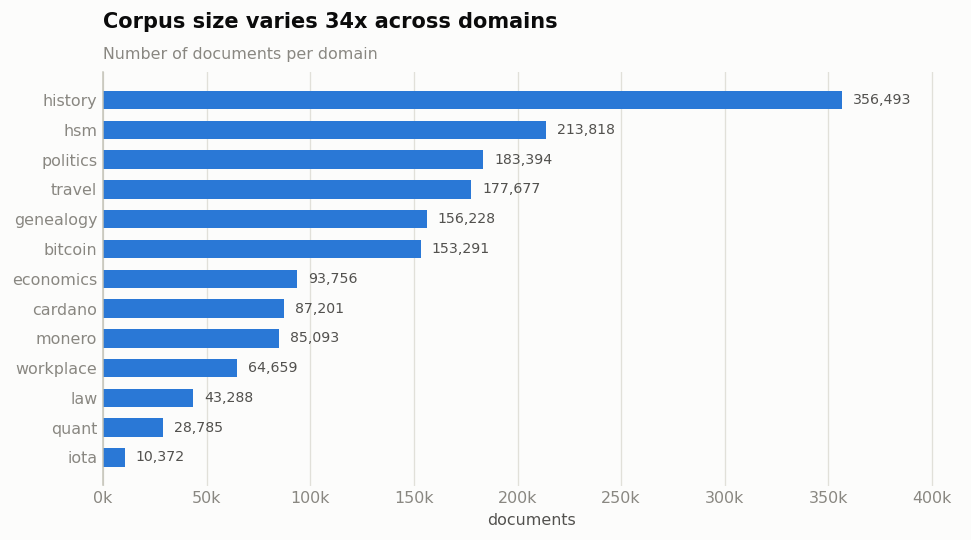

Largest : history       356,493  (21.6% of corpus)
Smallest: iota           10,372  (0.6% of corpus)
Ratio   : 34x


In [5]:
order = sorted(domains, key=lambda d: corpus[d]["n_docs"], reverse=True)
sizes = [corpus[d]["n_docs"] for d in order]

fig, ax = plt.subplots(figsize=(8.2, 4.6))
bars = ax.barh(range(len(order)), sizes, color=BLUE, height=0.62)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.invert_yaxis()
label_bars(ax, bars, sizes)
ax.set_xlim(0, max(sizes) * 1.16)
ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f}k")

finish(ax,
       "Corpus size varies 34x across domains",
       subtitle="Number of documents per domain",
       xlabel="documents", grid_axis="x")
plt.tight_layout()
plt.show()

print(f"Largest : {order[0]:<12}{sizes[0]:>9,}  "
      f"({100 * sizes[0] / total_docs:.1f}% of corpus)")
print(f"Smallest: {order[-1]:<12}{sizes[-1]:>9,}  "
      f"({100 * sizes[-1] / total_docs:.1f}% of corpus)")
print(f"Ratio   : {sizes[0] / sizes[-1]:.0f}x")

Kho văn bản mất cân bằng mạnh giữa các nhóm.

Điều này ảnh hưởng tới chi phí tính toán: một phương pháp cần xử lý toàn bộ kho
(ví dụ mã hoá bằng mô hình học sâu) sẽ tốn phần lớn thời gian cho vài nhóm lớn nhất.

## 3. Độ dài văn bản

Độ dài được đo bằng **số từ**, tách theo khoảng trắng.

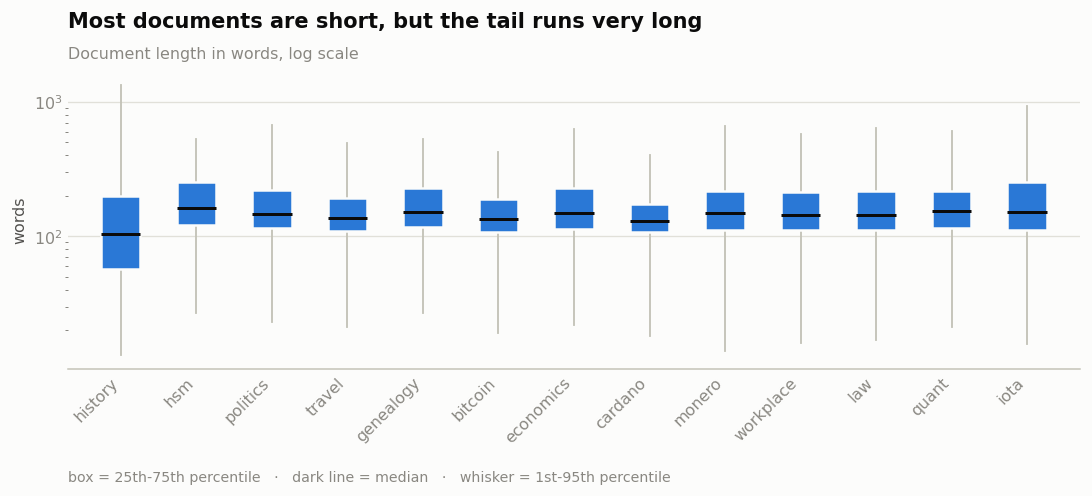

In [6]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))

p01, p25, p50, p75, p95 = (
    [corpus[d]["length_percentiles"][i] for d in order] for i in range(5))

for i in range(len(order)):
    # Whisker first, box over it, median on top
    ax.plot([i, i], [p01[i], p95[i]], color=AXIS, linewidth=1.1, zorder=1)
    ax.add_patch(plt.Rectangle((i - 0.26, p25[i]), 0.52, p75[i] - p25[i],
                               facecolor=BLUE, edgecolor=SURFACE,
                               linewidth=1.5, zorder=2))
    # Median in dark ink: a surface-coloured line reads as a gap, not a marker
    ax.plot([i - 0.26, i + 0.26], [p50[i], p50[i]],
            color=INK, linewidth=1.8, zorder=3, solid_capstyle="butt")

ax.set_yscale("log")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_xlim(-0.7, len(order) - 0.3)

finish(ax,
       "Most documents are short, but the tail runs very long",
       subtitle="Document length in words, log scale",
       ylabel="words",
       note="box = 25th-75th percentile   ·   dark line = median   ·   "
            "whisker = 1st-95th percentile")
plt.tight_layout()
plt.show()

In [7]:
print(f"{'domain':<12}{'p50':>8}{'mean':>9}{'p95':>9}{'max':>12}")
print("-" * 50)
for d in order:
    p = corpus[d]["length_percentiles"]
    print(f"{d:<12}{p[2]:>8.0f}{corpus[d]['length_mean']:>9.0f}"
          f"{p[4]:>9.0f}{corpus[d]['length_max']:>12,}")

domain           p50     mean      p95         max
--------------------------------------------------
history          104      471     1340      43,745
hsm              163      360      530     391,219
politics         146      331      679     470,813
travel           137      237      497     377,060
genealogy        152      373      532     839,850
bitcoin          134      376      422   1,513,968
economics        150      325      626     272,386
cardano          129      414      405     992,360
monero           148      482      657     823,419
workplace        145      275      582     281,075
law              145      332      641     272,386
quant            153      318      613     249,933
iota             152      681      936     272,386


Hai điểm đáng chú ý:

1. **Trung vị ổn định** quanh 150 từ ở hầu hết các nhóm — phần lớn văn bản là
   đoạn ngắn, cỡ một đoạn văn.
2. **Trung bình cao hơn trung vị rất nhiều**, và giá trị lớn nhất lên tới hàng
   trăm nghìn từ. Phân bố có **đuôi dài**: một số ít văn bản cực dài kéo trung
   bình lên.

Hệ quả cho thiết kế hệ thống: các mô hình học sâu chỉ xử lý được một số lượng từ
giới hạn (thường 256–512). Với phần lớn văn bản điều này không thành vấn đề,
nhưng những văn bản ở phần đuôi sẽ bị cắt mất hầu hết nội dung.

## 4. Văn bản trùng lặp

Phần này đếm số văn bản **có nội dung giống hệt nhau** nhưng được lưu dưới các
mã khác nhau.

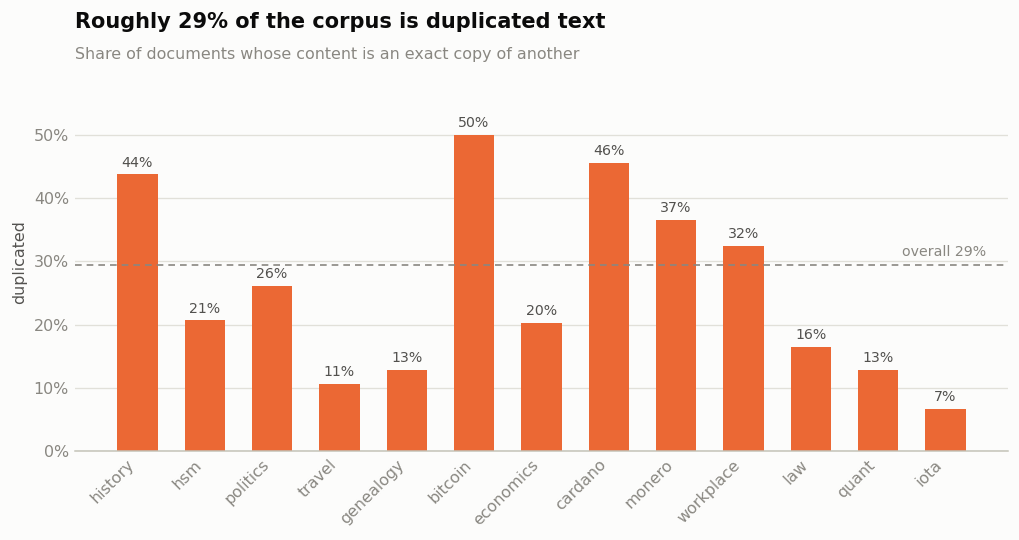

Total documents : 1,654,055
Distinct content: 1,168,372
Duplicated      : 485,683  (29.4%)


In [8]:
dup_pct = [100 * (corpus[d]["n_docs"] - corpus[d]["n_distinct"]) / corpus[d]["n_docs"]
           for d in order]

fig, ax = plt.subplots(figsize=(8.6, 4.6))
bars = ax.bar(range(len(order)), dup_pct, color=ORANGE, width=0.6)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
label_bars(ax, bars, dup_pct, fmt="{:.0f}%", horizontal=False)
ax.set_ylim(0, max(dup_pct) * 1.2)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")

overall = 100 * (1 - total_distinct / total_docs)
ax.axhline(overall, color=INK_MUTED, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.text(len(order) - 0.4, overall + 1.5, f"overall {overall:.0f}%",
        ha="right", fontsize=8.5, color=INK_MUTED)

finish(ax,
       f"Roughly {overall:.0f}% of the corpus is duplicated text",
       subtitle="Share of documents whose content is an exact copy of another",
       ylabel="duplicated")
plt.tight_layout()
plt.show()

print(f"Total documents : {total_docs:,}")
print(f"Distinct content: {total_distinct:,}")
print(f"Duplicated      : {total_docs - total_distinct:,}  ({overall:.1f}%)")

In [9]:
# How large do duplicate groups get? A group of size 1 is a unique document.
print(f"{'domain':<12}{'largest group':>15}{'docs in groups > 1':>21}")
print("-" * 49)
for d in order:
    groups = {int(k): v for k, v in corpus[d]["duplicate_group_sizes"].items()}
    in_duplicates = sum(size * n for size, n in groups.items() if size > 1)
    print(f"{d:<12}{max(groups):>15,}{in_duplicates:>21,}")

domain        largest group   docs in groups > 1
-------------------------------------------------
history                 524              200,816
hsm                      60               66,818
politics                 32               68,095
travel                  102               31,565
genealogy                42               31,056
bitcoin                 448              107,829
economics                50               29,947
cardano                 460               59,030
monero                  512               44,230
workplace                84               30,262
law                      31               11,495
quant                    13                5,830
iota                     92                  975


> ### Vấn đề 1 — Trùng lặp nội dung
>
> Gần một phần ba kho văn bản là bản sao. Một số nhóm vượt quá 60%.
>
> Hệ quả:
>
> - **Lãng phí tính toán:** mọi phép xử lý chạy trên toàn kho đều xử lý lại cùng
>   một nội dung nhiều lần.
> - **Chiếm chỗ trong kết quả:** nếu một văn bản đúng có nhiều bản sao, danh sách
>   10 kết quả đầu có thể bị lấp đầy bởi các bản sao của cùng một nội dung.
> - **Không thể loại bỏ tuỳ tiện:** bản được giữ lại có thể không phải bản được
>   ghi trong danh sách đáp án. Notebook 01b đo mức độ ảnh hưởng.

## 5. Cấu trúc mã tài liệu

Quan sát ban đầu cho thấy mã tài liệu xuất hiện dưới hai dạng:

| Dạng | Ví dụ |
| --- | --- |
| `long` | `iota/470_68d2fff7515d039b_93.txt` |
| `short` | `iota/a7dc25f7_0169.txt` |

Phần này kiểm tra hai dạng phân bố ra sao, và quan trọng hơn: **đáp án có phân bố
đều giữa hai dạng không**.

In [10]:
gold_shapes = {}
for d in domains:
    gold = set()
    with open(DATA / d / "qrels_train.txt", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                qid, _, doc_id, relevance = line.split()
                if int(relevance) > 0:
                    gold.add(doc_id)
    gold_shapes[d] = Counter(id_shape(g) for g in gold)

print(f"{'domain':<12}{'short in corpus':>17}{'short in gold':>16}{'gold docs':>12}")
print("-" * 57)
for d in order:
    n = corpus[d]["n_docs"]
    in_corpus = 100 * corpus[d]["id_shapes"].get("short", 0) / n
    n_gold = sum(gold_shapes[d].values())
    in_gold = 100 * gold_shapes[d].get("short", 0) / max(n_gold, 1)
    print(f"{d:<12}{in_corpus:>16.1f}%{in_gold:>15.1f}%{n_gold:>12,}")

domain        short in corpus   short in gold   gold docs
---------------------------------------------------------
history                100.0%          100.0%       2,546
hsm                     13.3%          100.0%         252
politics                19.2%          100.0%         283
travel                  18.4%          100.0%         190
genealogy               11.4%          100.0%         233
bitcoin                 20.4%          100.0%         232
economics               28.6%          100.0%         203
cardano                 15.8%          100.0%          80
monero                  21.5%          100.0%         122
workplace               23.6%          100.0%          73
law                     26.5%          100.0%          77
quant                   24.1%          100.0%          61
iota                    23.1%          100.0%          29


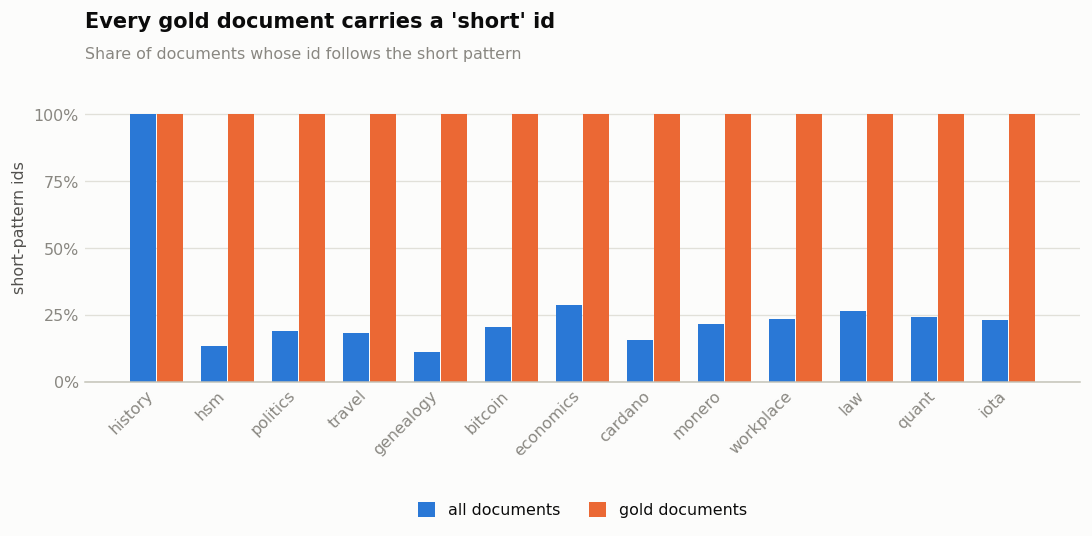

In [11]:
corpus_short = [100 * corpus[d]["id_shapes"].get("short", 0) / corpus[d]["n_docs"]
                for d in order]
gold_short = [100 * gold_shapes[d].get("short", 0)
              / max(sum(gold_shapes[d].values()), 1) for d in order]

fig, ax = plt.subplots(figsize=(9.2, 5.0))
x = np.arange(len(order))
ax.bar(x - 0.19, corpus_short, width=0.36, color=BLUE, label="all documents")
ax.bar(x + 0.19, gold_short, width=0.36, color=ORANGE, label="gold documents")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylim(0, 116)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")

finish(ax,
       "Every gold document carries a 'short' id",
       subtitle="Share of documents whose id follows the short pattern",
       ylabel="short-pattern ids")
legend_below(ax, ncol=2, y=-0.34)
plt.tight_layout()
plt.show()

> ### Vấn đề 2 — Mã tài liệu để lộ đáp án
>
> Biểu đồ cho thấy một chênh lệch có hệ thống: trong toàn kho, mã dạng `short`
> chỉ chiếm khoảng 11–26% ở hầu hết các nhóm, nhưng trong tập đáp án tỉ lệ này
> là **100%**.
>
> Nói cách khác, **mọi tài liệu là đáp án đều có mã dạng `short`**. Chỉ cần lọc
> theo dạng mã là loại bỏ được 75–89% kho văn bản mà **không mất một đáp án nào**.
>
> Đây là **dấu vết của quy trình xây dựng bộ dữ liệu**, không phải đặc tính của
> bài toán truy hồi theo thời gian.
>
> **Không sử dụng đặc điểm này trong hệ thống dự thi**, vì ba lý do:
>
> 1. Nó không giải quyết bài toán, chỉ khai thác cách bộ dữ liệu được tạo ra.
> 2. Không có gì bảo đảm đặc điểm này còn đúng trên tập test ẩn.
> 3. Kết quả thu được sẽ không phản ánh chất lượng thực của hệ thống.
>
> Phát hiện này chỉ nên được **ghi nhận trong báo cáo** như một nhận xét về chất
> lượng bộ dữ liệu.
>
> Ngoại lệ: nhóm `history` có 100% mã dạng `short` ở cả kho lẫn đáp án, nên ở
> nhóm này đặc điểm trên không tạo ra chênh lệch.

## 6. Tổng hợp phần 1

| # | Phát hiện | Ảnh hưởng tới thiết kế hệ thống |
| --- | --- | --- |
| 1 | Kho mất cân bằng, nhóm lớn nhất gấp nhóm nhỏ nhất ~34 lần | Chi phí tính toán tập trung ở vài nhóm |
| 2 | Độ dài văn bản có đuôi dài, tối đa hàng trăm nghìn từ | Cần cắt bớt khi đưa vào mô hình |
| 3 | Khoảng 30% văn bản là bản sao, có nhóm trên 60% | Lãng phí tính toán; bản sao chiếm chỗ trong kết quả |
| 4 | Mã tài liệu để lộ đâu là đáp án | Ghi nhận trong báo cáo, **không đưa vào hệ thống** |

**Tiếp theo:** Notebook 01b — khảo sát câu hỏi và đáp án.